### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.linear_model import Ridge
import lightgbm as lgbm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


### Read files & submission file for template

In [3]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

In [4]:
X_train.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP'],
      dtype='str')

### Features

In [5]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [7]:
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(axis = 1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(axis = 1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(axis = 1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(axis = 1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')


In [14]:
for i in [3,5,10,20]:
    X_train[f'FLOW_MEAN_{i}'] = X_train[SIGNED_VOLUME_features[:i]].mean(axis=1)
    X_test[f'FLOW_MEAN_{i}'] = X_test[SIGNED_VOLUME_features[:i]].mean(axis=1)

for i in [5,10,20]:
    X_train[f'FLOW_IMBALANCE_{i}'] = X_train[SIGNED_VOLUME_features[:i]].sum(axis=1)
    X_test[f'FLOW_IMBALANCE_{i}'] = X_test[SIGNED_VOLUME_features[:i]].sum(axis=1)

for i in [10,20]:
    X_train[f'FLOW_STD_{i}'] = X_train[SIGNED_VOLUME_features[:i]].std(axis=1)
    X_test[f'FLOW_STD_{i}'] = X_test[SIGNED_VOLUME_features[:i]].std(axis=1)

X_train['FLOW_SHOCK'] = X_train['SIGNED_VOLUME_1'] - X_train[SIGNED_VOLUME_features[:5]].mean(axis=1)
X_test['FLOW_SHOCK'] = X_test['SIGNED_VOLUME_1'] - X_test[SIGNED_VOLUME_features[:5]].mean(axis=1)

In [15]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

In [16]:
flow_features = [
    'FLOW_MEAN_3',
    'FLOW_MEAN_5',
    'FLOW_MEAN_10',
    'FLOW_MEAN_20',
    'FLOW_IMBALANCE_5',
    'FLOW_IMBALANCE_10',
    'FLOW_IMBALANCE_20',
    'FLOW_STD_10',
    'FLOW_STD_20',
    'FLOW_SHOCK'
]

features += flow_features

In [17]:
# 1. GROUP one-hot encoding
group_train = pd.get_dummies(X_train['GROUP'], prefix='GROUP')
group_test = pd.get_dummies(X_test['GROUP'], prefix='GROUP')

# 2. align train / test columns
group_train, group_test = group_train.align(group_test, join='outer', axis=1, fill_value=0)

# 3. concat
X_train = pd.concat([X_train, group_train], axis=1)
X_test = pd.concat([X_test, group_test], axis=1)

# 4. add to feature list
group_features = list(group_train.columns)
features = features + group_features

In [18]:
features

['RET_1',
 'RET_2',
 'RET_3',
 'RET_4',
 'RET_5',
 'RET_6',
 'RET_7',
 'RET_8',
 'RET_9',
 'RET_10',
 'RET_11',
 'RET_12',
 'RET_13',
 'RET_14',
 'RET_15',
 'RET_16',
 'RET_17',
 'RET_18',
 'RET_19',
 'RET_20',
 'SIGNED_VOLUME_1',
 'SIGNED_VOLUME_2',
 'SIGNED_VOLUME_3',
 'SIGNED_VOLUME_4',
 'SIGNED_VOLUME_5',
 'SIGNED_VOLUME_6',
 'SIGNED_VOLUME_7',
 'SIGNED_VOLUME_8',
 'SIGNED_VOLUME_9',
 'SIGNED_VOLUME_10',
 'SIGNED_VOLUME_11',
 'SIGNED_VOLUME_12',
 'SIGNED_VOLUME_13',
 'SIGNED_VOLUME_14',
 'SIGNED_VOLUME_15',
 'SIGNED_VOLUME_16',
 'SIGNED_VOLUME_17',
 'SIGNED_VOLUME_18',
 'SIGNED_VOLUME_19',
 'SIGNED_VOLUME_20',
 'MEDIAN_DAILY_TURNOVER',
 'AVERAGE_PERF_3',
 'AVERAGE_PERF_5',
 'AVERAGE_PERF_10',
 'AVERAGE_PERF_15',
 'AVERAGE_PERF_20',
 'ALLOCATIONS_AVERAGE_PERF_3',
 'ALLOCATIONS_AVERAGE_PERF_5',
 'ALLOCATIONS_AVERAGE_PERF_10',
 'ALLOCATIONS_AVERAGE_PERF_15',
 'ALLOCATIONS_AVERAGE_PERF_20',
 'STD_PERF_20',
 'ALLOCATIONS_STD_PERF_20',
 'FLOW_MEAN_3',
 'FLOW_MEAN_5',
 'FLOW_MEAN_10',
 'F

### Fitting one simple Ridge

In [19]:
train_dates = np.sort(X_train["TS"].unique())

kf = KFold(n_splits=8, shuffle = True, random_state = 42)

scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(train_dates), 1):

    train_ts = train_dates[train_idx]
    valid_ts = train_dates[valid_idx]

    train_mask = X_train["TS"].isin(train_ts)
    valid_mask = X_train["TS"].isin(valid_ts)

    X_tr = X_train.loc[train_mask, features].fillna(0)
    X_va = X_train.loc[valid_mask, features].fillna(0)

    y_tr = y_train.loc[train_mask].values.ravel()
    y_va = y_train.loc[valid_mask].values.ravel()

    model = Ridge(alpha = 1)
    model.fit(X_tr, y_tr)

    pred = model.predict(X_va)

    acc = accuracy_score(
        (y_va > 0).astype(int),
        (pred > 0).astype(int),
    )

    scores.append(acc)
    print(f"Fold {fold}: {acc:.4f}")

mean_acc = np.mean(scores)
std_acc = np.std(scores)

print(f"Mean accuracy: {mean_acc:.4f}")
print(f"Std: {std_acc:.4f}")
print(f"Range: [{mean_acc-std_acc:.4f}, {mean_acc+std_acc:.4f}]")

Fold 1: 0.5215
Fold 2: 0.5215
Fold 3: 0.5179
Fold 4: 0.5221
Fold 5: 0.5081
Fold 6: 0.5200
Fold 7: 0.5220
Fold 8: 0.5260
Mean accuracy: 0.5199
Std: 0.0049
Range: [0.5149, 0.5248]


In [ ]:
log = pd.DataFrame(columns=["exp", "change", "model", "cv_mean", "cv_std"])

In [20]:
new_ridge = linear_model.Ridge(alpha=1)

new_ridge.fit(X_train[features].to_numpy(na_value=0),y_train.to_numpy(na_value=0))

preds_ridge = pd.DataFrame(new_ridge.predict(X_test[features].fillna(0).to_numpy(na_value=0)), index = sample_submission.index,columns=['target'])

In [ ]:
# (preds_ridge>0).astype(int).to_csv('preds_ridge_bench.csv')
(preds_ridge>0).astype(int).to_csv('../submissions/preds_ridge_add_volFLOW_group.csv')

### Fitting a lightgbm using cross validation

In [22]:
features_lgbm = features

In [23]:
features

['RET_1',
 'RET_2',
 'RET_3',
 'RET_4',
 'RET_5',
 'RET_6',
 'RET_7',
 'RET_8',
 'RET_9',
 'RET_10',
 'RET_11',
 'RET_12',
 'RET_13',
 'RET_14',
 'RET_15',
 'RET_16',
 'RET_17',
 'RET_18',
 'RET_19',
 'RET_20',
 'SIGNED_VOLUME_1',
 'SIGNED_VOLUME_2',
 'SIGNED_VOLUME_3',
 'SIGNED_VOLUME_4',
 'SIGNED_VOLUME_5',
 'SIGNED_VOLUME_6',
 'SIGNED_VOLUME_7',
 'SIGNED_VOLUME_8',
 'SIGNED_VOLUME_9',
 'SIGNED_VOLUME_10',
 'SIGNED_VOLUME_11',
 'SIGNED_VOLUME_12',
 'SIGNED_VOLUME_13',
 'SIGNED_VOLUME_14',
 'SIGNED_VOLUME_15',
 'SIGNED_VOLUME_16',
 'SIGNED_VOLUME_17',
 'SIGNED_VOLUME_18',
 'SIGNED_VOLUME_19',
 'SIGNED_VOLUME_20',
 'MEDIAN_DAILY_TURNOVER',
 'AVERAGE_PERF_3',
 'AVERAGE_PERF_5',
 'AVERAGE_PERF_10',
 'AVERAGE_PERF_15',
 'AVERAGE_PERF_20',
 'ALLOCATIONS_AVERAGE_PERF_3',
 'ALLOCATIONS_AVERAGE_PERF_5',
 'ALLOCATIONS_AVERAGE_PERF_10',
 'ALLOCATIONS_AVERAGE_PERF_15',
 'ALLOCATIONS_AVERAGE_PERF_20',
 'STD_PERF_20',
 'ALLOCATIONS_STD_PERF_20',
 'FLOW_MEAN_3',
 'FLOW_MEAN_5',
 'FLOW_MEAN_10',
 'F

In [24]:

# A quite large number of trees with low depth to prevent overfits
lgbm_params = {
                "objective": "mse",
                "metric": "mse",
                "num_threads": 50,
                "seed": 42,
                "verbosity": -1,
                'learning_rate': 1e-2,
                'max_depth': 3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8
scores_lgbm = []
models_lgbm = []
 
splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True,).split(train_dates)

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
    y_local_train = y_train.loc[local_train_ids,'target']
    
    X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
    y_local_test = y_train.loc[local_test_ids,'target']
    
    X_local_train = X_local_train
    X_local_test = X_local_test

    train_data = lgbm.Dataset(X_local_train, label=y_local_train.values) 
    
    model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
    
    y_local_pred = model_lgbm.predict(X_local_test.values, num_threads = lgbm_params['num_threads'])
    
    
    models_lgbm.append(model_lgbm)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_lgbm.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_lgbm)*100
std = np.std(scores_lgbm)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


Fold 1 - Accuracy: 52.04%
Fold 2 - Accuracy: 52.40%
Fold 3 - Accuracy: 52.19%
Fold 4 - Accuracy: 52.14%
Fold 5 - Accuracy: 51.98%
Fold 6 - Accuracy: 52.45%
Fold 7 - Accuracy: 52.44%
Fold 8 - Accuracy: 52.15%
Accuracy: 52.22% [52.05 ; 52.39] (+- 0.17)


/var/folders/jc/m7g4_5nd1vg1lww0rp52j2fr0000gn/T/ipykernel_26956/3401225653.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]


<Axes: >

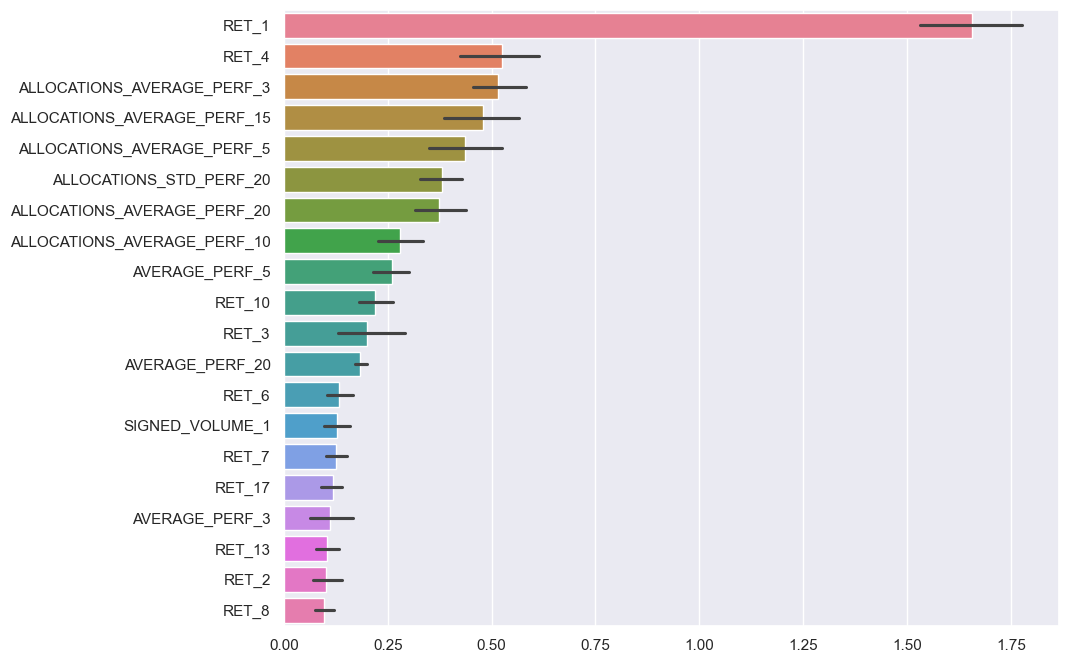

In [25]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)


In [26]:
train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train) 

model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index,columns=['target']) 


In [ ]:
#(preds_lgbm>0).astype(int).to_csv('preds_lgbm_bench.csv')
(preds_lgbm>0).astype(int).to_csv('../submissions/preds_lgbm_add_features.csv')